In [ ]:
import gtsam
import numpy as np
import matplotlib.pyplot as plt
from gtbook.display import show
from gtsam.symbol_shorthand import X, L
from gtsam import symbolChr, symbolIndex
import gtsam.utils.plot as gtsam_plot
from utils.utils_math import kstr, pose2_to_array, rotmat2
from simulation.data_generator_nonlinear import RobotSimulatorSE2
from div.tuning import NonlinearSimParams, NonlinearFactorGraphParams
from utils.utils_gtsam import reorder_covariance_auto
from models.dynamicmodels import OdometrySE2
from models.measurementmodels import RangeBearing
from tqdm import tqdm

### Create factor graph

In [ ]:
from simulation.create_paths import make_circle_data, make_figure8_data

poses, landmarks, obs = make_circle_data(radius=20.0, n_poses=40, n_landmarks=60, max_range=30.0)  
#poses, landmarks, obs = make_figure8_data(a=10.0, n_poses=50, n_landmarks=30, max_range=20.0)

# Create simulation configuration
simParams = NonlinearSimParams(
    poses=poses, 
    landmarks=landmarks, 
    observations=obs,
    Q_vec = np.array([0.1, 0.1, 0.04]),    # Process noise (x,y,psi)
    R_vec = np.array([np.deg2rad(1.0), 0.1]),          # Measurement (bearing, range) | 0.05, 0.1
    P_x0_vec = np.array([0.01, 0.01, 0.001]), # Prior noise
    odom_seed=42,
    meas_seed=42,
)

# simParams = NonlinearSimParams(
#     poses=[
#         np.array([0.0, 0.0, 0.0]),  # X0
#         np.array([2.0, 0.0, 0.0]),  # X1
#         np.array([0.0, 0.0, 0.0])   # X2
#     ],
#     landmarks=[
#         np.array([2.0, 2.0]),  # L0
#         np.array([4.0, 2.0]),  # L1
#     ],
#     observations={ # could potentially use max distance to determine this
#         0: [0],     # X0 sees L0
#         1: [0],     # X1 sees L0
#         2: [0,1]    # X2 sees L0 & L1
#     },
#     Q_vec = np.array([0.02, 0.02, 0.01]),   # Process noise
#     R_vec = np.array([0.02, 0.05]),         # Measurement
#     P_x0_vec = np.array([0.01, 0.01, 0.01]) # Prior noise
# )

# simParams = NonlinearSimParams(
#     poses=[
#         np.array([0.0, 0.0, np.pi/2]),  # X0
#         np.array([0.0, 2.0, np.pi/2]),  # X1
#         np.array([0.0, 4.0, np.pi/2]),  # X2
#         np.array([0.0, 6.0, np.pi/2]),  # X3
#         np.array([0.0, 8.0, np.pi/2])   # X4

#     ],
#     landmarks=[
#         np.array([2.0, 2.0]),  # L0
#         np.array([4.0, 2.0]),  # L1
#         np.array([4.0, 4.0]),  # L2
#         np.array([6.0, 5.0]),  # L3
#         np.array([5.0, 7.0])   # L4
#     ],
#     observations={ # could potentially use max distance to determine this
#         0: [0,1,2],
#         1: [0,1,2,3,4],
#         2: [0,1,2],
#         3: [2,3,4],
#         4: [0,1,2,3,4]    
#     },
#     Q_vec = np.array([0.1, 0.1, 0.05]),     # Process noise
#     R_vec = np.array([0.1, 0.05]),          # Measurement
#     P_x0_vec = np.array([0.05, 0.05, 0.05]), # Prior noise

#     odom_seed=42,
#     meas_seed=42,
# )

simulator = RobotSimulatorSE2(simParams)
sim_data = simulator.simulate()

fgParams = NonlinearFactorGraphParams(
    Q_vec = simParams.Q_vec*2,
    R_vec = simParams.R_vec*2,
    P_x0_vec = simParams.P_x0_vec,
    association_type = 'jcbb',       # 'known' or 'jcbb' TODO
    alpha_individual = 0.999,       # confidence levels for individual compatibility test
    alpha_joint = 0.9999,            # confidence levels for joint compatibility test
    r_local = 35.0,                  # local feature filtering radius for JCBB TODO:
    use_isam = False,
    
)


pose_vars = [X(i) for i in range(len(sim_data['ground_truth']['poses']))]
landmark_vars = [L(i) for i in range(len(sim_data['ground_truth']['landmarks']))]
all_vars = pose_vars + landmark_vars

In [3]:
from nonlinear.factor_graph_slam_new import FactorGraphSLAM, SLAMVisualizer

prior_pose = sim_data['measurements']['prior']
gt_associations = sim_data['associations']
slam = FactorGraphSLAM(fgParams, prior_pose, gt_associations)

# Main loop

for k in tqdm(range(len(pose_vars))):
    # Get odometry (None for first step)
    if k > 0:
        odometry, _, _ = sim_data['measurements']['odometry'][k - 1]
    else:
        odometry = None
    
    # Get landmark measurements
    measurements = sim_data['measurements']['landmarks'][k]
    # gt_associations = sim_data['gt_associations'][k] # Indices of observed landmarks at step k 
    
    jcbb_associations = None  # Not used in this example
    
    # Process step
    slam.process_step(odometry, measurements)

# Main loop
poses_dr = [prior_pose]
for k in range(len(pose_vars)):
    # Get odometry (None for first step)
    if k > 0:
        odometry, _, _ = sim_data['measurements']['odometry'][k - 1]
        pose_next = poses_dr[-1].compose(odometry)
        poses_dr.append(pose_next)

100%|██████████| 40/40 [00:11<00:00,  3.57it/s]


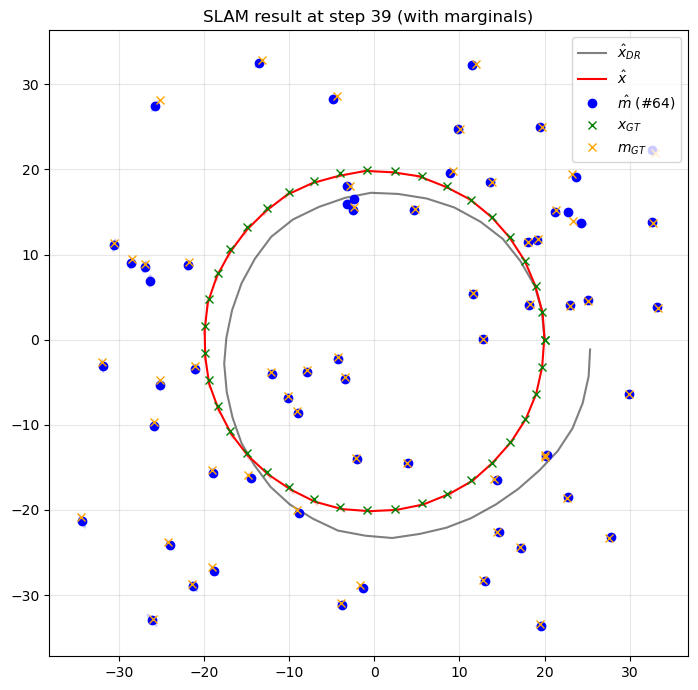

In [4]:
ground_truth = sim_data['ground_truth']

fig, ax = plt.subplots(figsize=(10, 7))
    
x_coords = [pose.x() for pose in poses_dr]
y_coords = [pose.y() for pose in poses_dr]
ax.plot(x_coords, y_coords, 'k-', alpha=0.5, label=r'$\hat{x}_{DR}$')

# Visualize
marginals = slam.get_marginals()
# SLAMVisualizer.plot_final_result(slam, marginals) #ground_truth['poses'], ground_truth['landmarks'])
SLAMVisualizer.plot_final_result(slam, marginals, ground_truth['poses'], ground_truth['landmarks'], ax=ax)
# SLAMVisualizer.plot_final_result(slam, marginals, ground_truth['poses'], ground_truth['landmarks'])
fig.savefig("../figures/jcbb_circle.pdf", bbox_inches="tight")

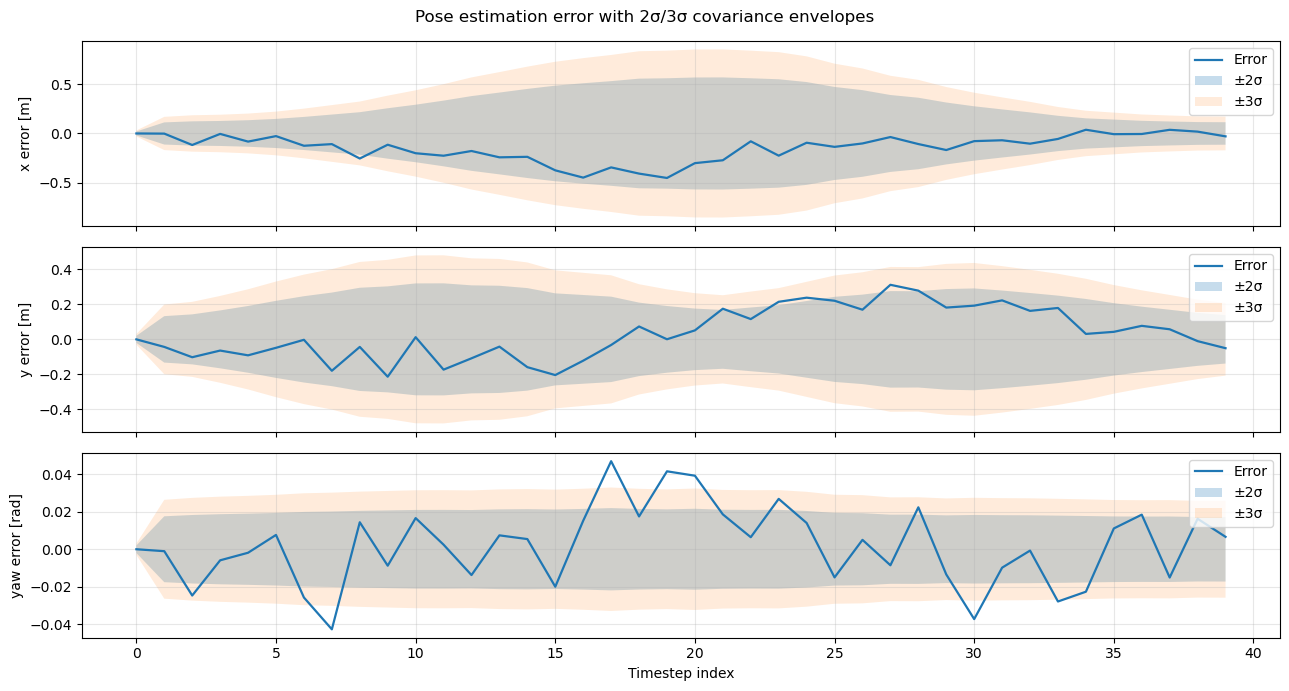

In [5]:
fig, ax = SLAMVisualizer.plot_error(slam, ground_truth['poses'])
fig.savefig("../figures/jcbb_circle_error.pdf", bbox_inches="tight")
plt.show()

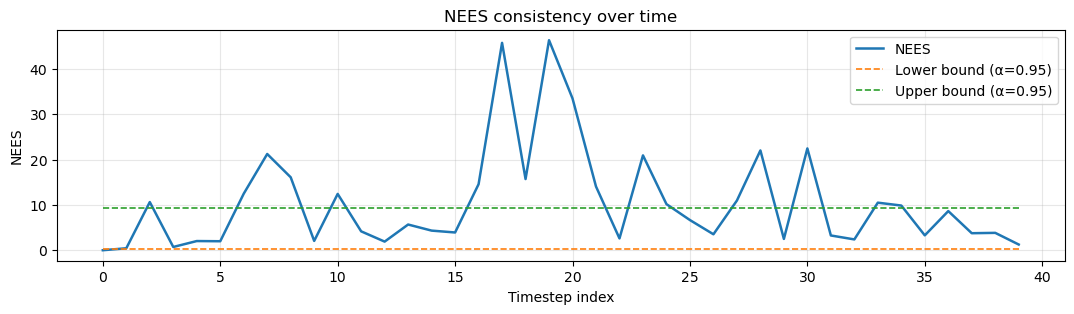

In [6]:
fig, ax = SLAMVisualizer.plot_NEES(slam, gt_poses=ground_truth['poses'])
fig.savefig("../figures/jcbb_circle_nees.pdf", bbox_inches="tight")
plt.show()


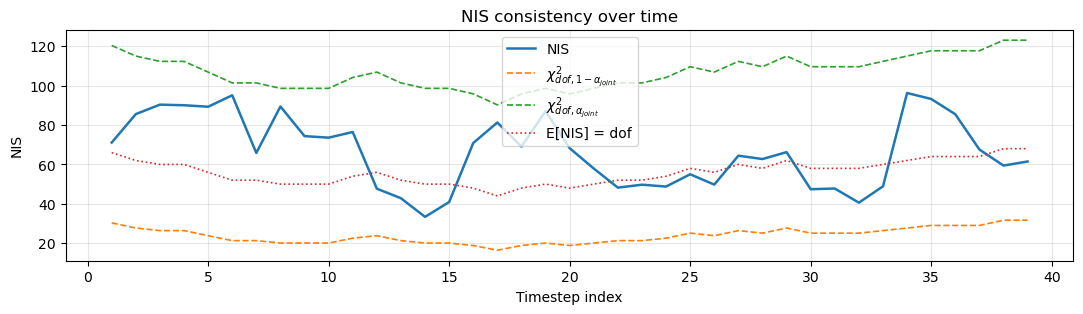

In [7]:
fig, ax = SLAMVisualizer.plot_NIS(slam)
fig.savefig("../figures/jcbb_circle_nis.pdf", bbox_inches="tight")
plt.show()

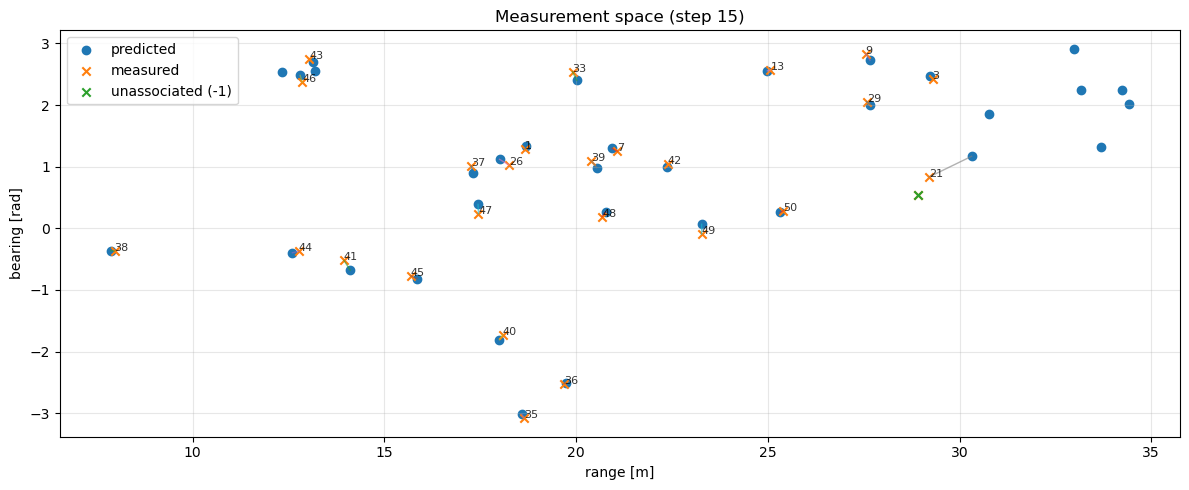

In [52]:
fig, ax = SLAMVisualizer.plot_measurement_space(slam, step=15, figsize=(12,5))
# fig.savefig("../figures/jcbb_circle_meas_space.pdf", bbox_inches="tight")
plt.show()

In [8]:
slam.history

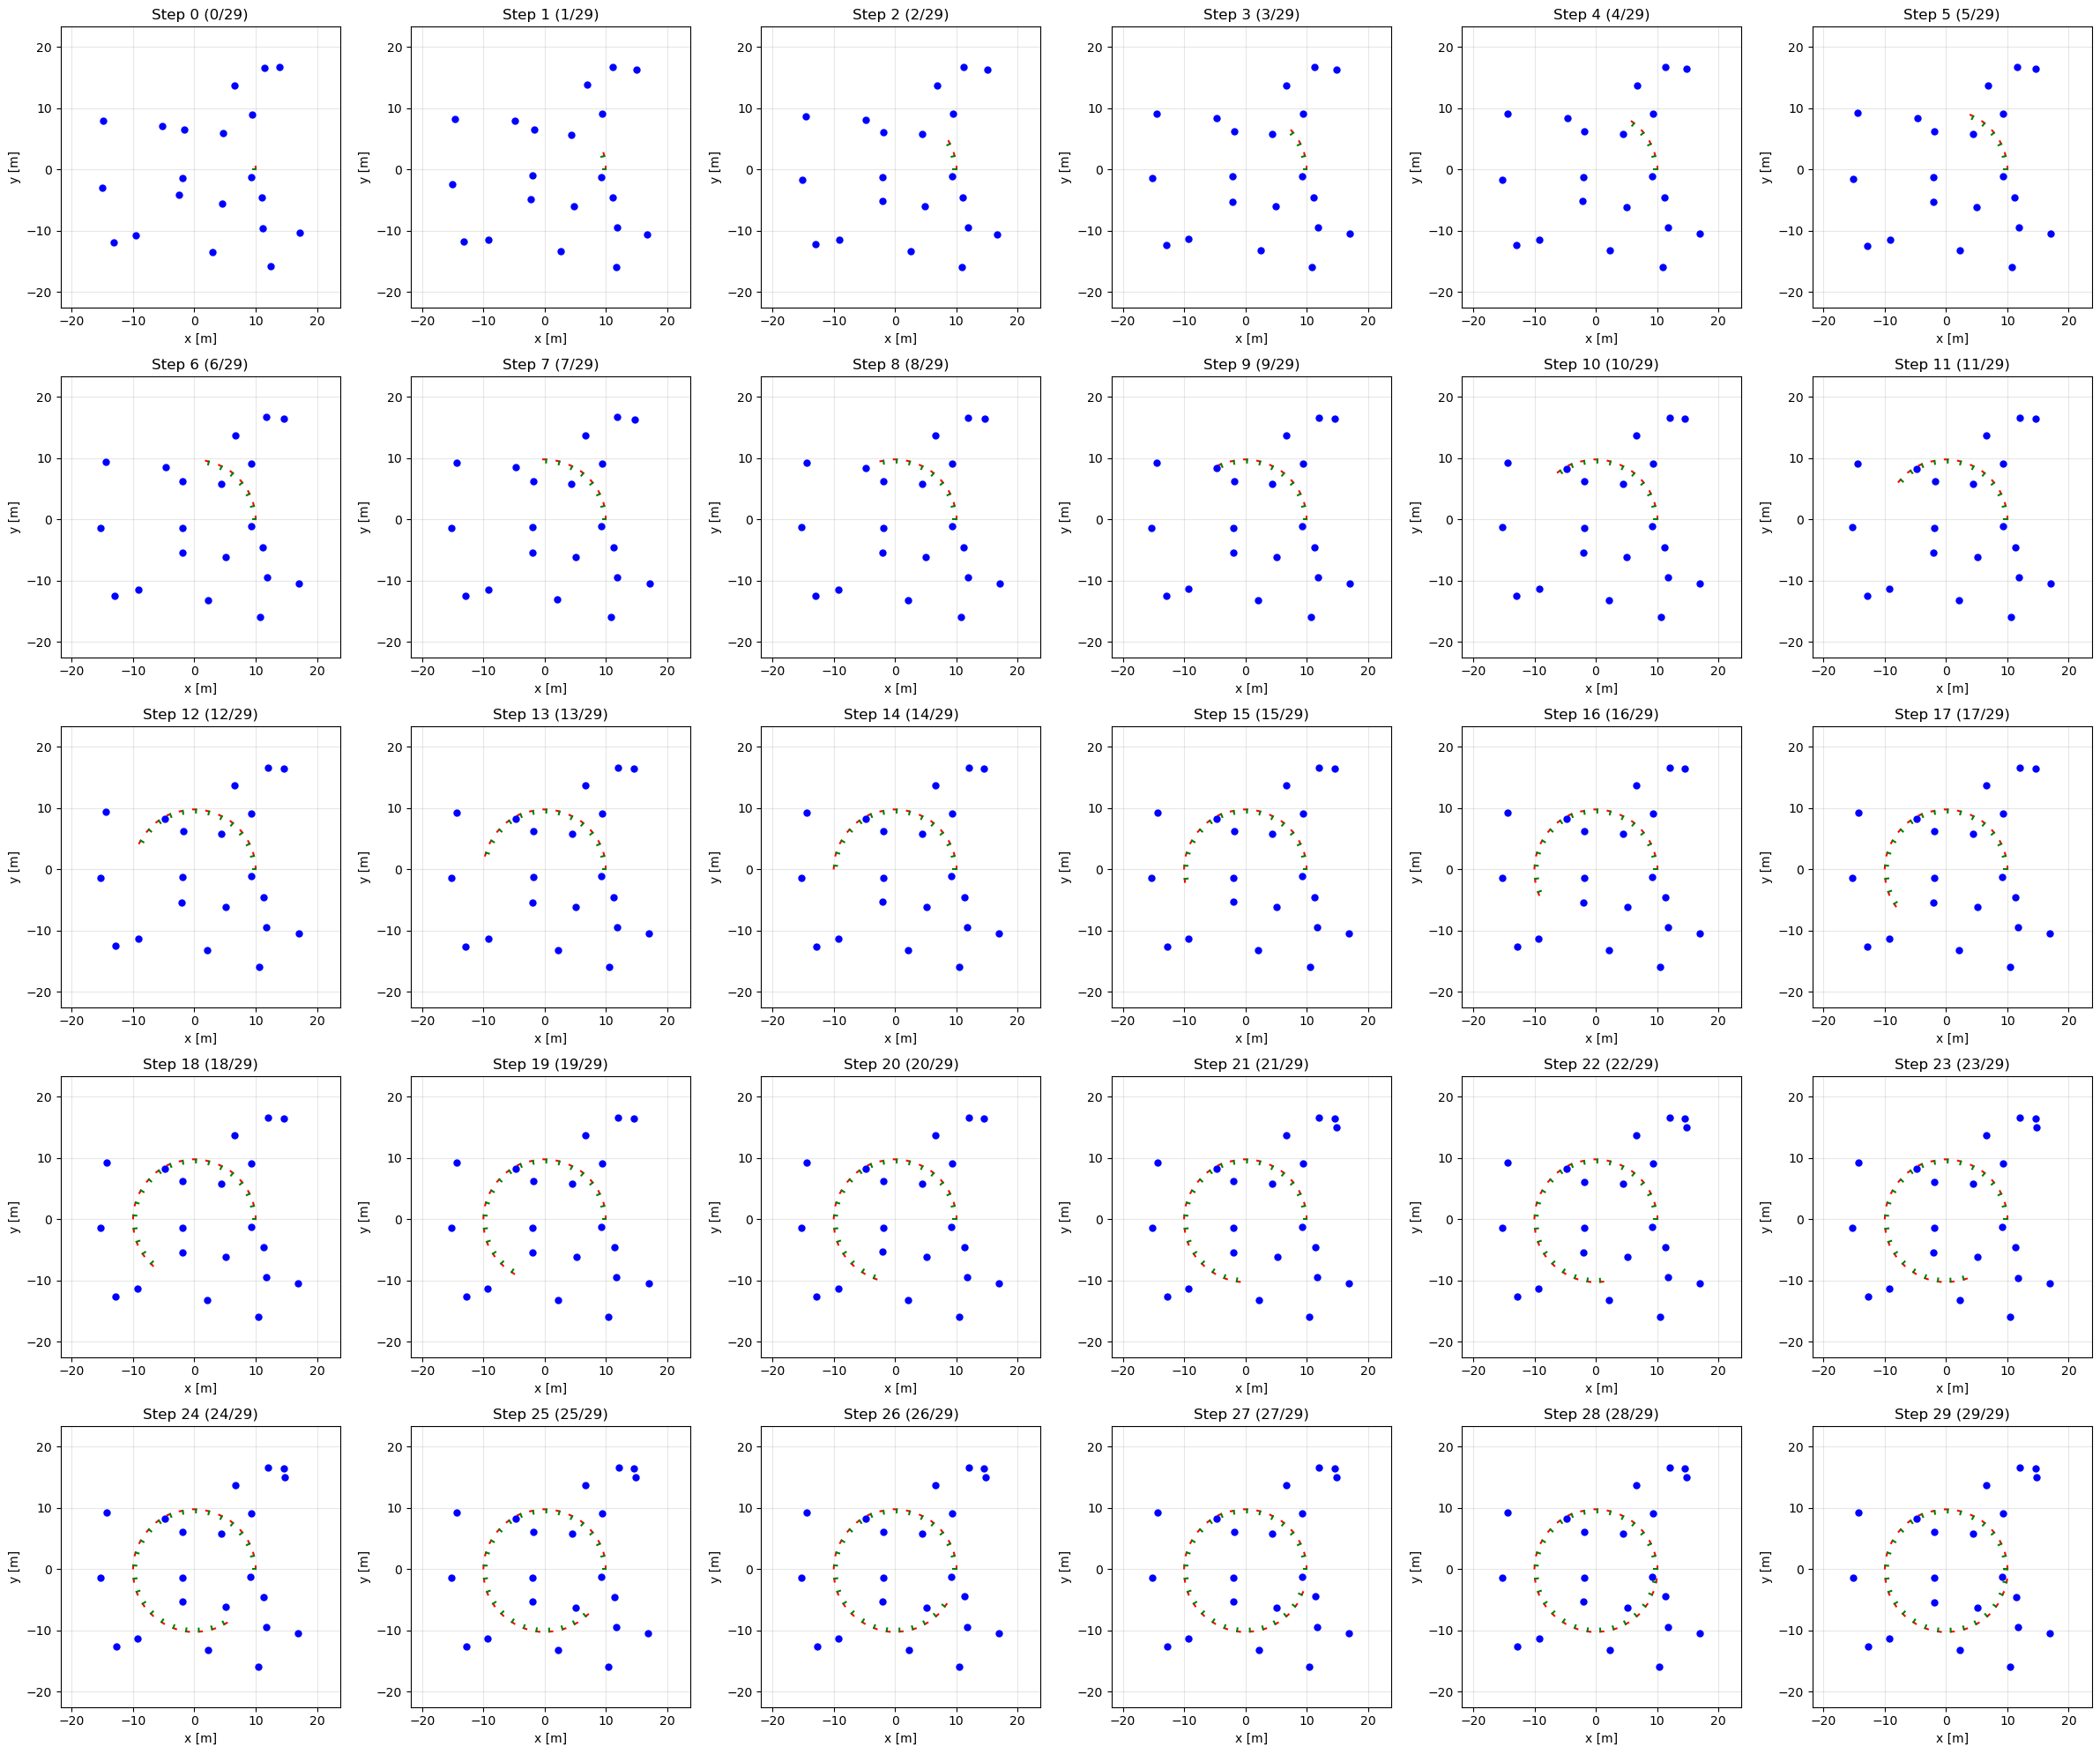

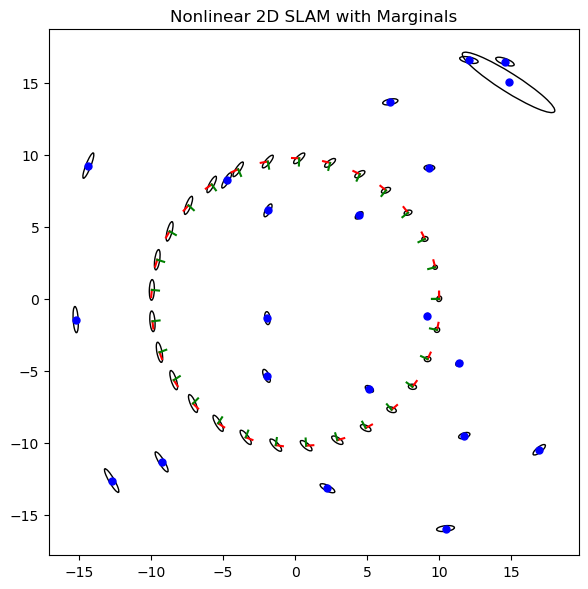

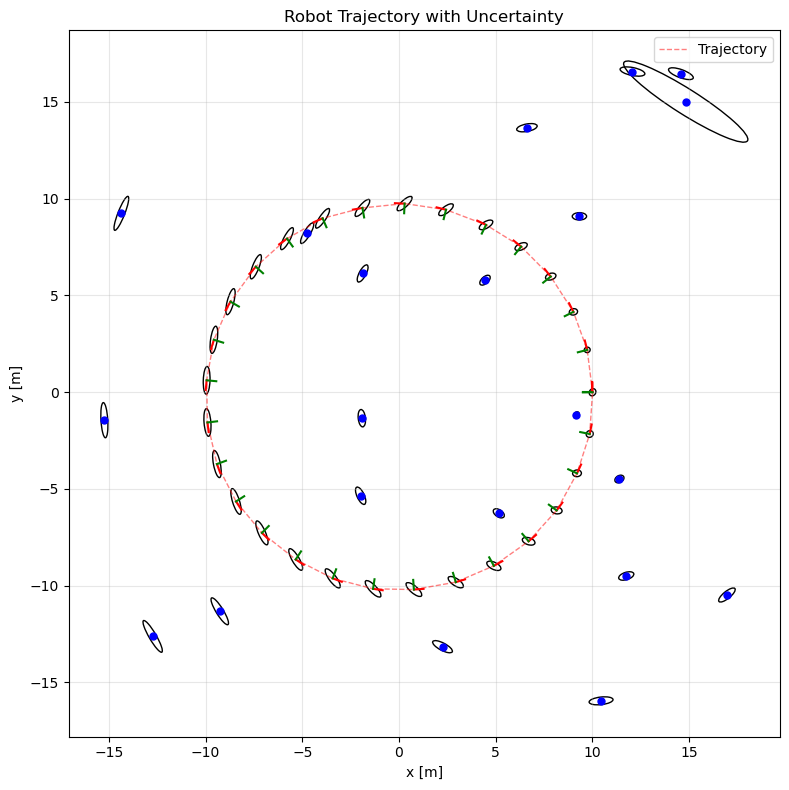

In [9]:
# After running SLAM...

# 1. Plot step-by-step evolution
fig, axes = SLAMVisualizer.plot_step_by_step(slam, subplot_size=4.0)
plt.show()

# 2. Plot final result with marginals
marginals = slam.get_marginals()
fig, ax = SLAMVisualizer.plot_final_result(slam, marginals)
plt.show()

# 3. Plot trajectory with uncertainty
fig, ax = SLAMVisualizer.plot_trajectory_with_uncertainty(slam)
plt.show()

### Raw loop

In [ ]:
"""Rotation used for coordinate transformations of covariance between local and world frame"""
def E(theta):
    M = np.eye(3)
    M[:2,:2] = rotmat2(theta)
    return M

In [ ]:
import gtsam
import numpy as np
import matplotlib.pyplot as plt
from gtsam.utils import plot as gtsam_plot
import copy
from association import JCBB
from utlities.utils import make_psd


# --- Setup ---
K = len(pose_vars)

prior_noise_model = gtsam.noiseModel.Diagonal.Sigmas(fgParams.P_x0_vec)
odometry_noise_model = gtsam.noiseModel.Diagonal.Sigmas(fgParams.Q_vec)
measurement_noise_model = gtsam.noiseModel.Diagonal.Sigmas(fgParams.R_vec)
params = gtsam.LevenbergMarquardtParams()

graph = gtsam.NonlinearFactorGraph()
estimate = gtsam.Values()

motion_model = OdometrySE2(sigma_x=fgParams.sigma_x,
                           sigma_y=fgParams.sigma_y,
                           sigma_theta=fgParams.sigma_theta)
sens_model = RangeBearing(sigma_range=fgParams.sigma_range,
                          sigma_bearing=fgParams.sigma_bearing)

# --- Add prior factor ---
prior_mean = sim_data['measurements']['prior']
graph.add(gtsam.PriorFactorPose2(X(0), prior_mean, prior_noise_model))
estimate.insert(X(0), prior_mean)

# --- Initial optimization ---
optimizer = gtsam.LevenbergMarquardtOptimizer(graph, estimate, params)
result = optimizer.optimize()

# --- Store all estimates for later visualization ---
estimates_over_time = [copy.deepcopy(result)]
Z_pred = []
Z = []
added_landmarks_keys = []
added_poses_keys = [X(0)]
nL = 0

# --- Main loop ---
for k in range(K):
    # Add odometry factors
    if k > 0:
        u_k, from_idx, to_idx = sim_data['measurements']['odometry'][k - 1]

        marginals = gtsam.Marginals(graph, estimate)

        graph.add(gtsam.BetweenFactorPose2(X(from_idx), X(to_idx), u_k, odometry_noise_model))
        added_poses_keys.append(X(to_idx))

        x_prev = estimate.atPose2(X(from_idx))
        x_pred = motion_model.f_x(pose2_to_array(x_prev), pose2_to_array(u_k))
        m_pred = np.zeros((len(added_landmarks_keys), 2))
        for i, key in enumerate(added_landmarks_keys):
            m_pred[i] = result.atPoint2(key)

        max_range = sens_model.max_range + 5  # some margin
        max_fov = sens_model.max_fov + 0.1  # some margin

        z_pred = sens_model.h(x_pred, m_pred) # (L,2)
        z_pred_filtered = []
        indices_filtered = []
        m_filtered = []

        for i, (z_i, m_i) in enumerate(zip(z_pred, m_pred)):
            if z_i[0] < max_range and abs(z_i[1]) < max_fov / 2:
                z_pred_filtered.append(z_i)
                indices_filtered.append(i)
                m_filtered.append(m_i)

        z_pred_filtered = np.array(z_pred_filtered)
        indices_filtered = np.array(indices_filtered)
        m_filtered = np.array(m_filtered)

        if len(indices_filtered) == 0:
            print("No landmarks in sensor range at step", k) 
        
        landmark_keys_filtered = [L(idx) for idx in indices_filtered]  
        last_pose_key = [X(k-1)]
        state_keys_filtered = last_pose_key + landmark_keys_filtered # TODO: predict covariance also before ...

        P_prev_filtered = marginals.jointMarginalCovariance(state_keys_filtered).fullMatrix()
        P_prev_filtered = reorder_covariance_auto(P_prev_filtered, source_keys=sorted(state_keys_filtered),
                                            target_keys=state_keys_filtered, values=result)
        
        Px_prev_filtered = P_prev_filtered[:3,:3]
        Ex = E(x_prev.theta())
        g_Px_prev = Ex @ Px_prev_filtered @ Ex.T
        _, g_Px_pred = motion_model.predict_pose(pose2_to_array(x_prev), g_Px_prev, pose2_to_array(u_k))

        P_pred_filtered = P_prev_filtered 
        P_pred_filtered[:3,:3] = g_Px_pred # Possible error here, currently correlation terms between pose and landmarks not updated 

        S_filtered = sens_model.predict_measurement_covariance(x_pred, m_filtered, P_pred_filtered)
        S_filtered = make_psd(S_filtered)

        x_pred_gtsam = x_prev.compose(u_k) # Predict next pose
        estimate.insert(X(to_idx), x_pred_gtsam)
    else:
        z_pred_filtered = np.array([])
        S_filtered = np.array([[]])

    alpha1 = 0.9999  # individual compatibility threshold
    alpha2 = 0.9999  # joint compatibility threshold

    # Perform JCBB data association
    z_list = sim_data['measurements']['landmarks'][k]
    z = np.array([[s, rot.theta()] for s, rot in z_list], dtype=float)

    Z_pred.append(z_pred_filtered)
    Z.append(z)

    associations = JCBB(z, z_pred_filtered, S_filtered, alpha1, alpha2)
    ids = sim_data['associations'][k]  # Ground-truth associations from simulator

    for j, (z_range, z_bearing) in zip(associations, z_list):
        if j == -1: # unassociated measurement
            graph.add(gtsam.BearingRangeFactor2D(X(k), L(nL), z_bearing, z_range, measurement_noise_model))
            delta_x = z_range * np.cos(z_bearing.theta())
            delta_y = z_range * np.sin(z_bearing.theta())
            predicted_pose = estimate.atPose2(X(k))
            landmark_initial = predicted_pose.transformFrom(gtsam.Point2(delta_x, delta_y))
            estimate.insert(L(nL), landmark_initial)
            added_landmarks_keys.append(L(nL))
            nL += 1
        else: # associated measurement with existing landmark
            graph.add(gtsam.BearingRangeFactor2D(X(k), L(j), z_bearing, z_range, measurement_noise_model)) 

    # Optimize after each step
    optimizer = gtsam.LevenbergMarquardtOptimizer(graph, estimate, params)
    result = optimizer.optimize()

    # Store result for visualization
    estimates_over_time.append(copy.deepcopy(result))

    # Update initial estimate for next iteration
    estimate = result

# --- Compute marginals for final result ---
marginals = gtsam.Marginals(graph, result)

print("Total number of landmarks added:", nL)

In [ ]:
 # --- Plot final result (JCBB vs ground truth) ---
def poses_to_xy(poses):
    xs = [p.x() for p in poses]
    ys = [p.y() for p in poses]
    return np.array(xs), np.array(ys)


# Estimated poses / landmarks (JCBB)
poses_est = [result.atPose2(key) for key in added_poses_keys]
x_est, y_est = poses_to_xy(poses_est)

landmarks_est = np.array(
    [result.atPoint2(key) for key in added_landmarks_keys]
) if len(added_landmarks_keys) > 0 else np.empty((0, 2))

# Ground truth poses / landmarks
sim_data_gt = sim_data['ground_truth']
poses_gt = sim_data_gt['poses']
landmarks_gt = sim_data_gt['landmarks']

x_gt, y_gt = poses_to_xy(poses_gt)
landmarks_gt_xy = np.array(landmarks_gt)

# --- Figure ---
fig, ax = plt.subplots(1, 1, figsize=(8.27, 8.27))
ax.set_aspect('equal', adjustable='box')

# Trajectories
ax.scatter(x_gt, y_gt, marker='x', s=60, color='orange', label='GT trajectory')
# ax.plot(x_gt, y_gt, 'x', color='orange', linewidth=3, label='GT trajectory')
# ax.plot(x_est, y_est, '*', linewidth=2, label='Estimated trajectory (JCBB)')

# Landmarks
if landmarks_gt_xy.size > 0:
    ax.scatter(
        landmarks_gt_xy[:, 0], landmarks_gt_xy[:, 1],
        marker='x', s=60, color='purple', label='GT landmarks'
    )


# (Optional) Covariance ellipses for poses and landmarks
# These are not used in the legend to avoid clutter.
# for pose_gt in poses_gt:
#     gtsam_plot.plot_pose2_on_axes(
#         ax, pose_gt, axis_length=0.2
#     )

for var in added_poses_keys:
    cov = marginals.marginalCovariance(var)
    mean = result.atPose2(var)
    gtsam_plot.plot_pose2_on_axes(
        ax, pose=mean, axis_length=0.5, covariance=cov
    )  # label omitted on purpose

for var in added_landmarks_keys:
    cov = marginals.marginalCovariance(var)
    mean = result.atPoint2(var)
    gtsam_plot.plot_point2_on_axes(
        ax, point=mean, linespec='b.', P=cov
    )  # label omitted on purpose

# Plot poses
# for k in range(slam.num_poses):
#     pose_key = X(k)
#     pose = slam.values.atPose2(pose_key)
#     cov = marginals.marginalCovariance(pose_key)
#     gtsam_plot.plot_pose2_on_axes(ax, pose=pose, axis_length=0.5, covariance=cov)

# # Plot landmarks
# for lm_key in slam.landmark_keys:
#     lm_pos = slam.values.atPoint2(lm_key)
#     cov = marginals.marginalCovariance(lm_key)
#     gtsam_plot.plot_point2_on_axes(ax, point=lm_pos, linespec='b', P=cov)

# Labels, legend, etc.
ax.set_title("Nonlinear 2D SLAM: SLAM with jcbb associations vs Ground Truth")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.grid(True, linestyle=':', linewidth=0.5)
ax.legend(loc='best')

plt.tight_layout()
plt.show()
# Save figure as PDF
fig.savefig('slam_jcbb_vs_g.pdf', format='pdf', bbox_inches='tight')

In [ ]:
from IPython.display import display

plt.ioff()  # Turn interactive mode off for static multi-plot display

# Create K subplots (arranged in a square-ish grid)
K = len(estimates_over_time)
cols = int(np.ceil(np.sqrt(K)))
rows = int(np.ceil(K / cols))

# Compute global axis limits across all saved estimates (poses + landmarks)
xs = []
ys = []
for est in estimates_over_time:
    for var in all_vars:
        if est.exists(var):
            if kstr(var)[0] == 'X':
                p = est.atPose2(var)
                xs.append(p.x())
                ys.append(p.y())
            elif kstr(var)[0] == 'L':
                l = est.atPoint2(var)
                xs.append(l[0])
                ys.append(l[1])

# Fallback if nothing collected
if len(xs) == 0:
    xs = [0]
    ys = [0]

xmin, xmax = min(xs), max(xs)
ymin, ymax = min(ys), max(ys)
# Add margin (20% of the max span, but at least 0.5 m)
xspan = max(1e-3, xmax - xmin)
yspan = max(1e-3, ymax - ymin)
margin_frac = 0.2
x_margin = max(0.5, margin_frac * xspan)
y_margin = max(0.5, margin_frac * yspan)

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
# Flatten axes for easy indexing
if isinstance(axes, np.ndarray):
    axes_flat = axes.flatten()
else:
    axes_flat = [axes]

for idx, est in enumerate(estimates_over_time):
    ax = axes_flat[idx]
    ax.set_aspect('equal')
    ax.set_title(f"Iteration {idx+1}/{K}")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")

    # Plot current poses and landmarks
    for var in all_vars:
        label = kstr(var)[0]
        if label == 'X' and est.exists(var):
            gtsam_plot.plot_pose2_on_axes(ax, est.atPose2(var), axis_length=0.5)
        elif label == 'L' and est.exists(var):
            gtsam_plot.plot_point2_on_axes(ax, est.atPoint2(var), linespec='b')

    # Apply the SAME global limits to each axis
    ax.set_xlim(xmin - x_margin, xmax + x_margin)
    ax.set_ylim(ymin - y_margin, ymax + y_margin)

# Hide any unused axes
for i in range(K, len(axes_flat)):
    fig.delaxes(axes_flat[i])

plt.tight_layout()
plt.show()

# Measurement and predicted measurement over time
for k in range(K):
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.set_aspect('equal')
    ax.set_title(f"Measurements at time step {k}")

    z = Z[k]
    z_pred = Z_pred[k]

    if z_pred.shape[0] > 0:
        ax.scatter(z_pred[:, 0], z_pred[:, 1], c='orange', label='Predicted Measurements', marker='x')

    if z.shape[0] > 0:
        ax.scatter(z[:,0], z[:,1], c='blue', label='Actual Measurements', marker='o')

    ax.set_xlabel("range [m]")
    ax.set_ylabel("bearing [rad]")
    ax.legend()
    plt.grid()
    plt.axis('equal')
    plt.show()

In [ ]:
P = np.array([[3, 0, 0],
              [0, 1, 0],
              [0, 0, 0.1]])

def R(theta):
    C = np.array([[np.cos(theta), -np.sin(theta), 0],
                  [np.sin(theta),  np.cos(theta), 0],
                  [0,              0,             1]])  
    return C

R(np.pi/2) @ P @ R(np.pi/2).T